Jun0523: This is a continuous, 47-minute file featuring stims. at minutes 5, 12, 19, 26, 33, and 40; the corresponding time steps would be 122175, 293220, 464265, 635310, 806355, and 977400. Note that all of the applied stimuli were identical except the one applied at 33 minutes: I ramped up the intensity of this stimulus to study the effects of perturbing the population and then reduced it back to baseline for the stimulus at 40 minutes.

In [2]:
## Import peaks from npy file
import numpy as np
peak_times = np.load('../data/sea_slug/Jun0523_peak_times.npy', allow_pickle=True).item()  # Load as dictionary

In [3]:
sr = 407.25
stimuli = [time / (sr * 60) for time in [122175, 293220, 464265, 635310, 806355, 977400]]

In [4]:
stimuli

[5.0, 12.0, 19.0, 26.0, 33.0, 40.0]

In [5]:
T = 47  # Total time in minutes

In [6]:
import matplotlib.pyplot as plt
## Compile with tikz and times font
plt.rc('text', usetex=True)
plt.rc('font', family='times')

In [7]:
import hep

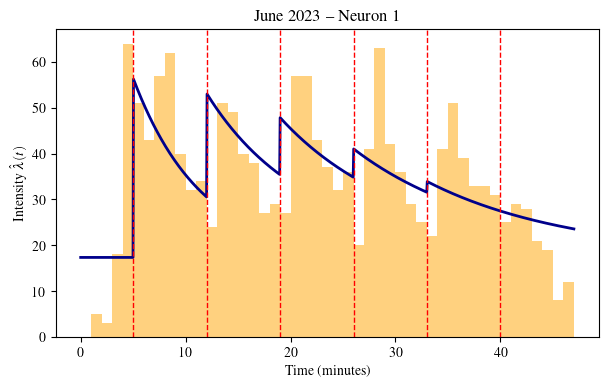

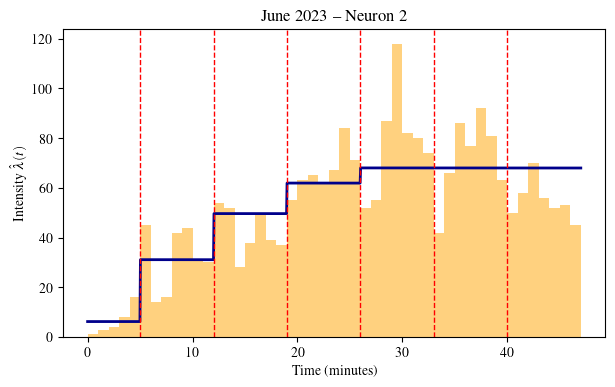

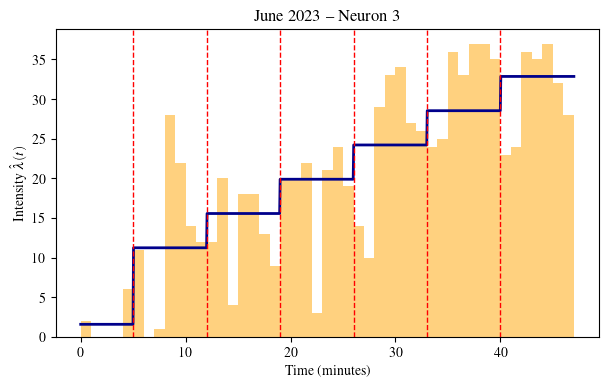

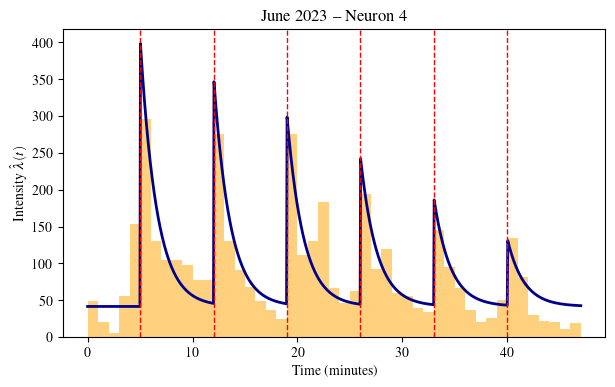

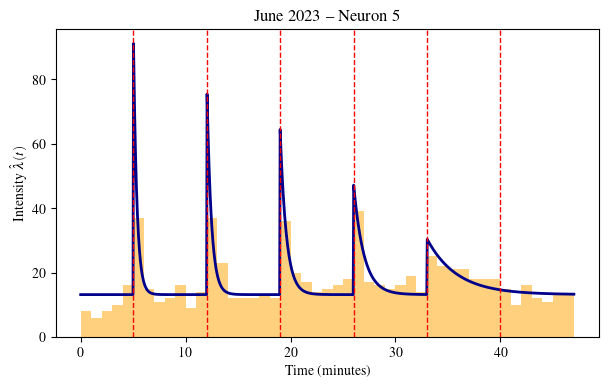

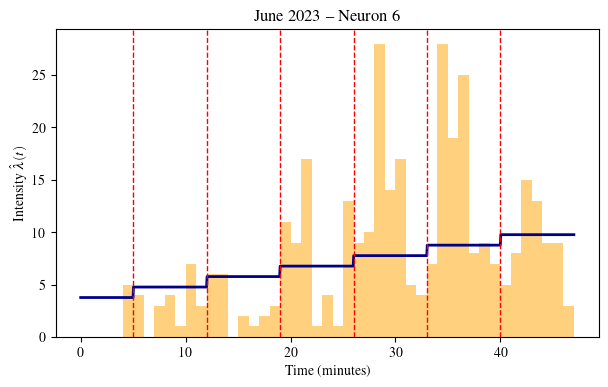

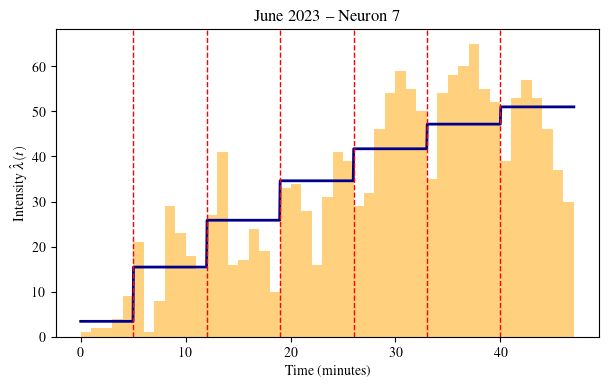

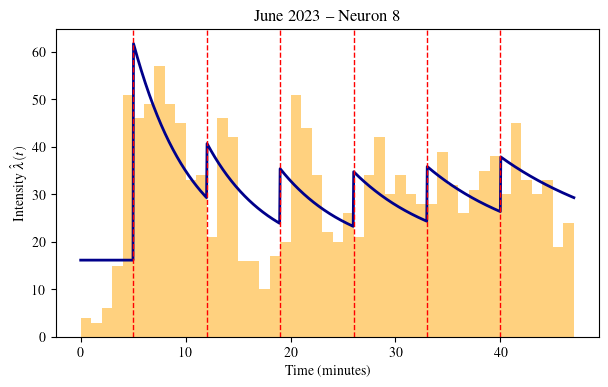

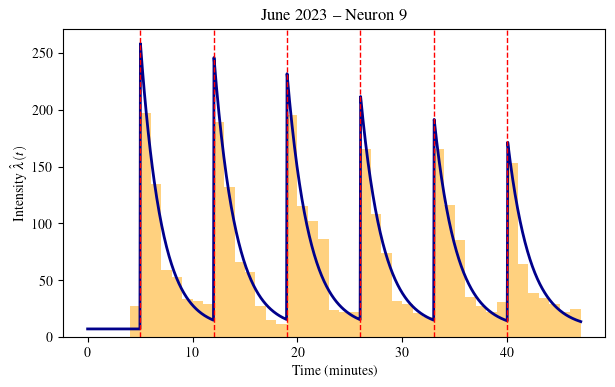

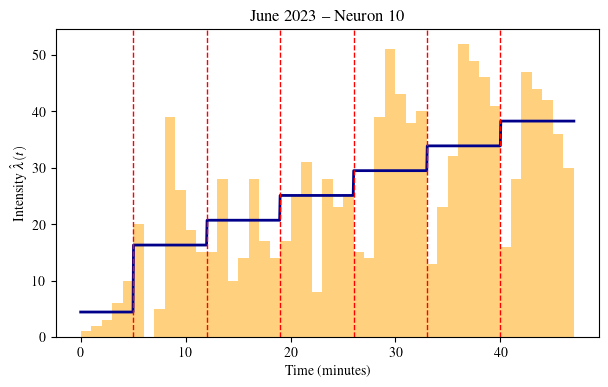

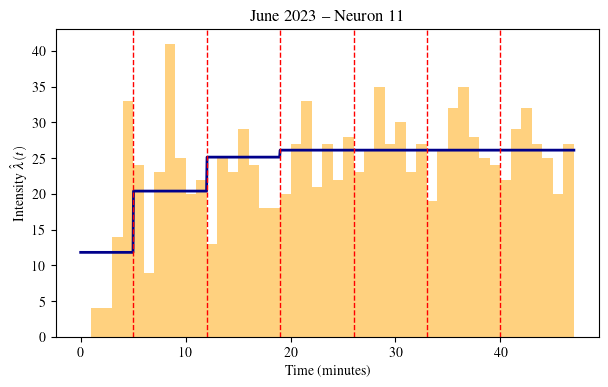

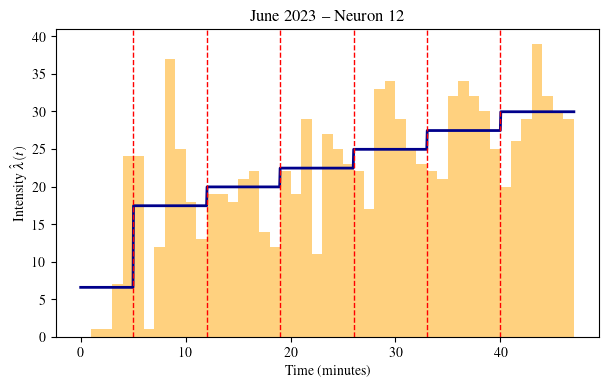

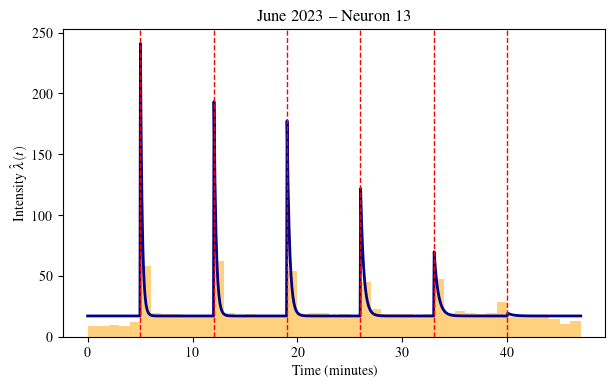

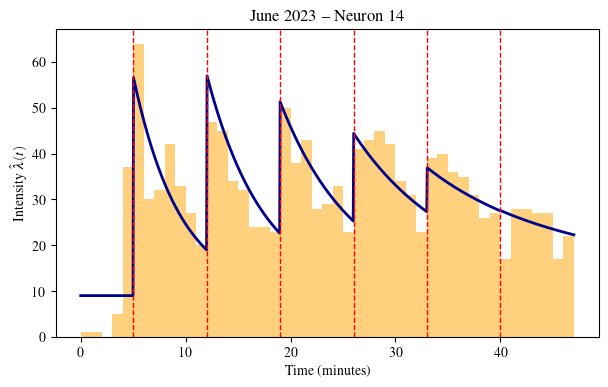

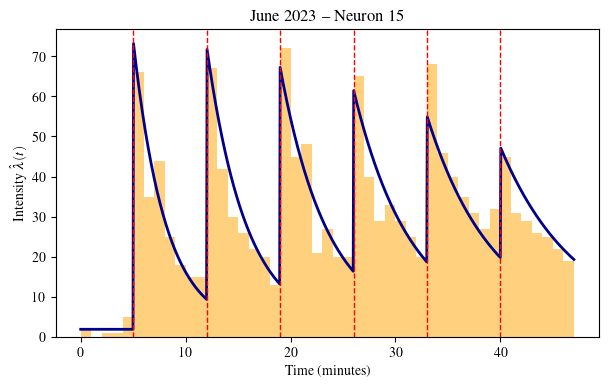

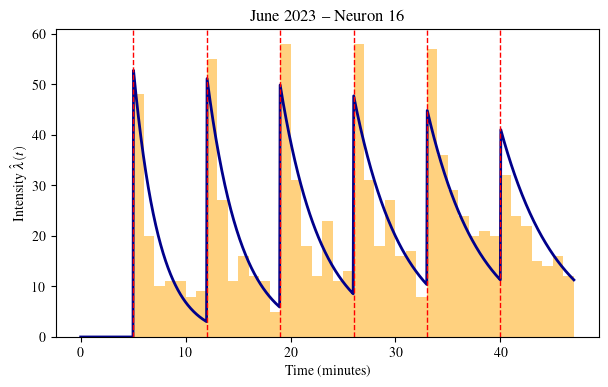

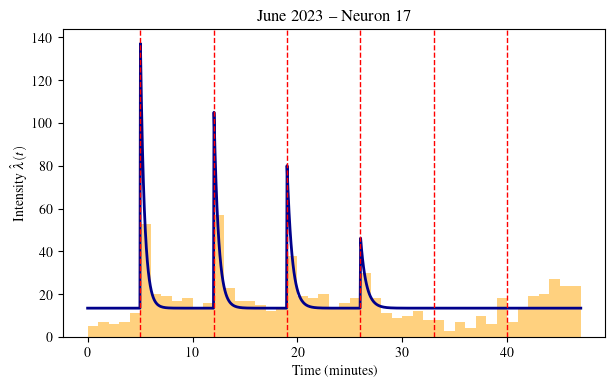

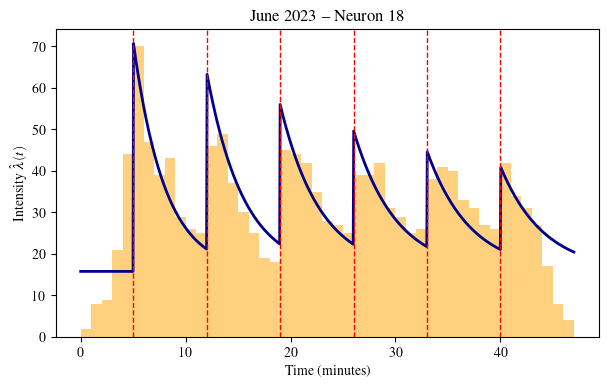

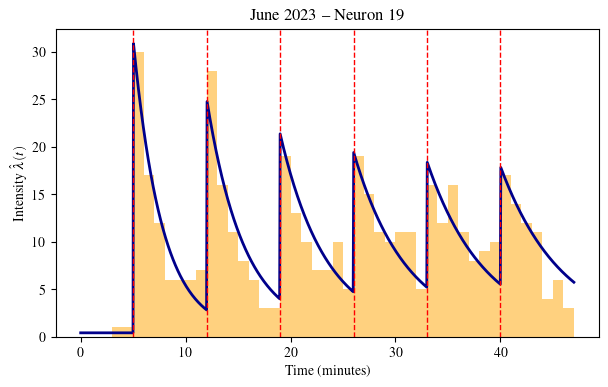

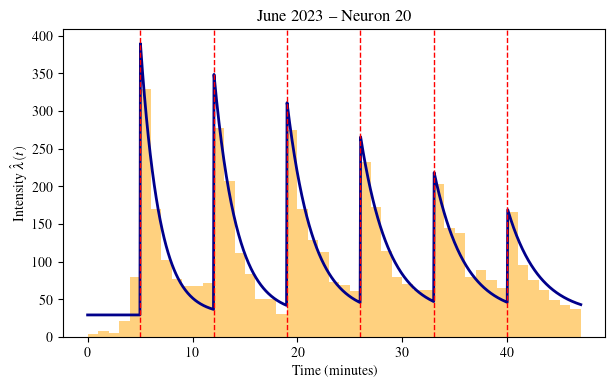

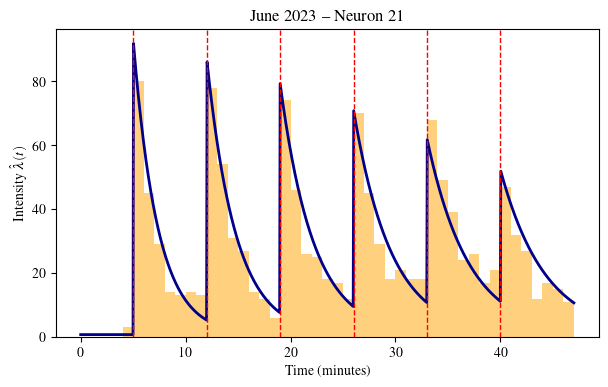

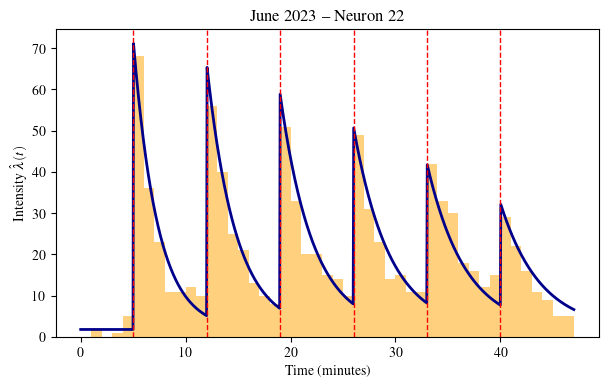

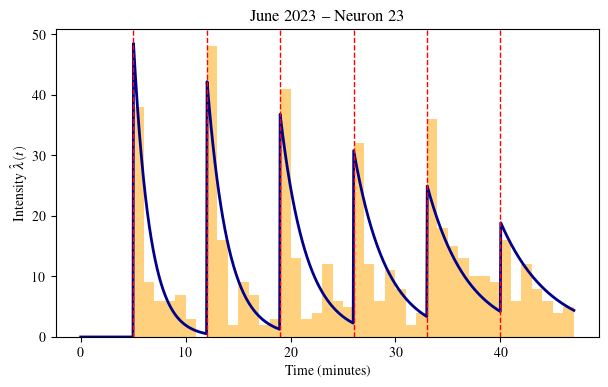

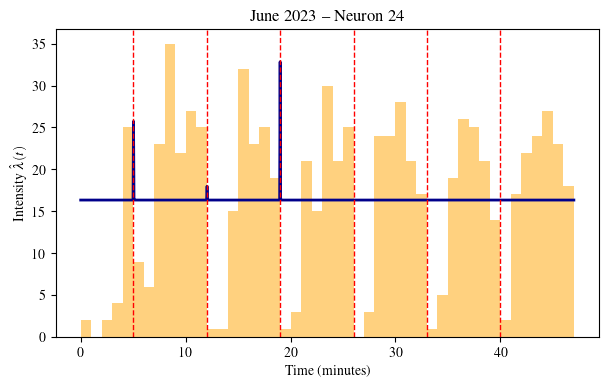

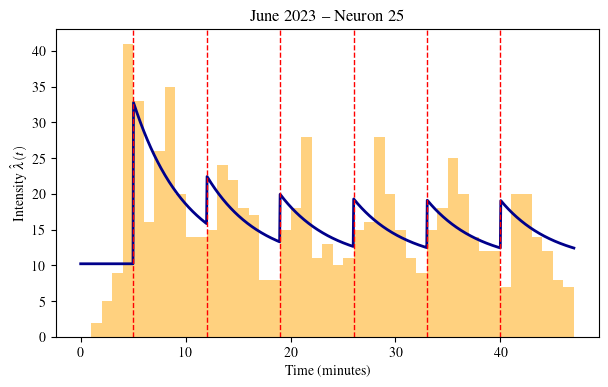

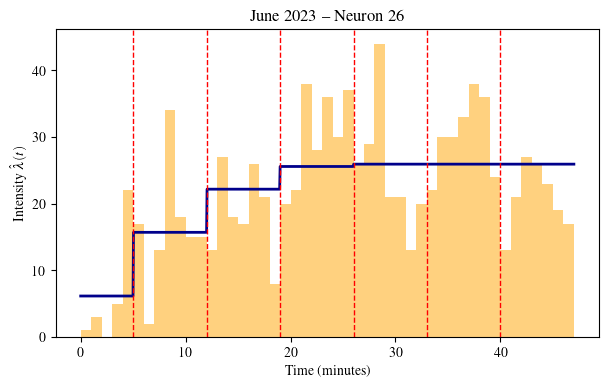

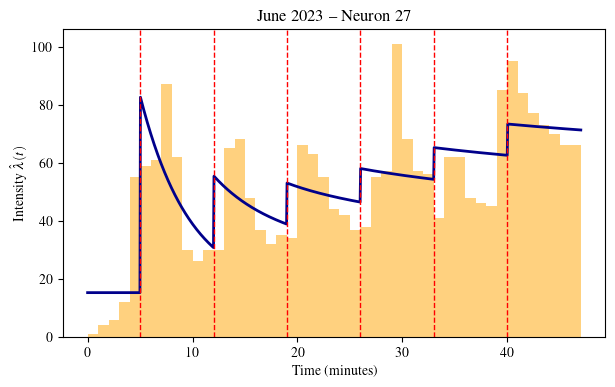

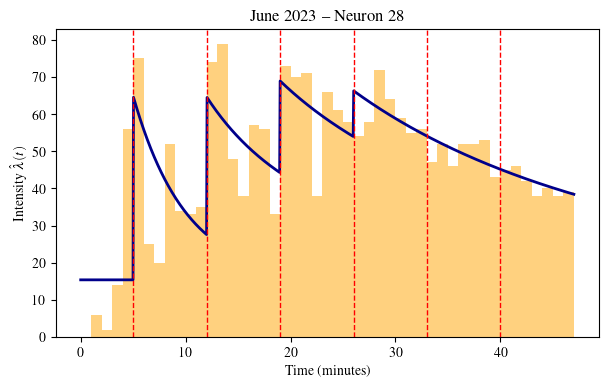

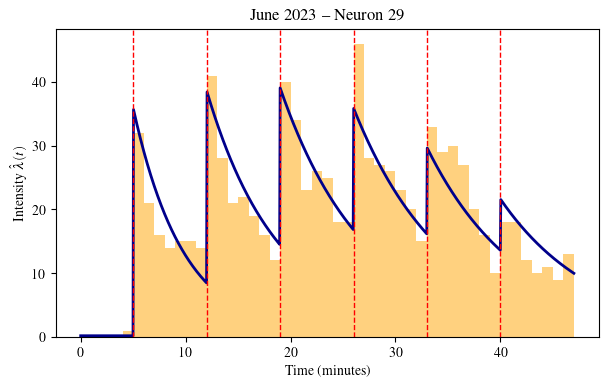

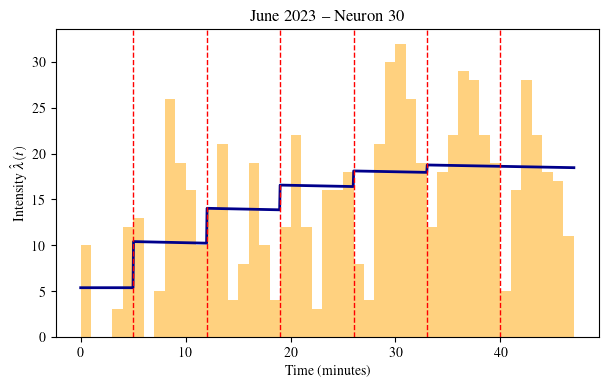

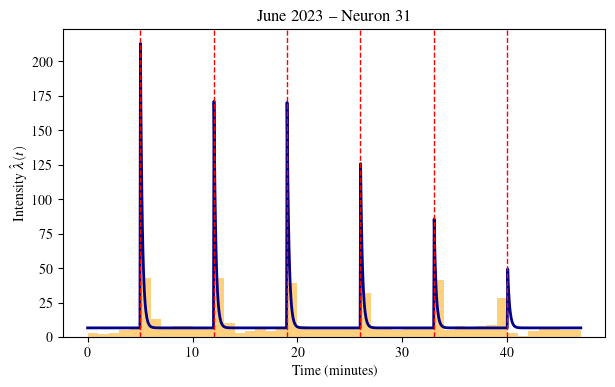

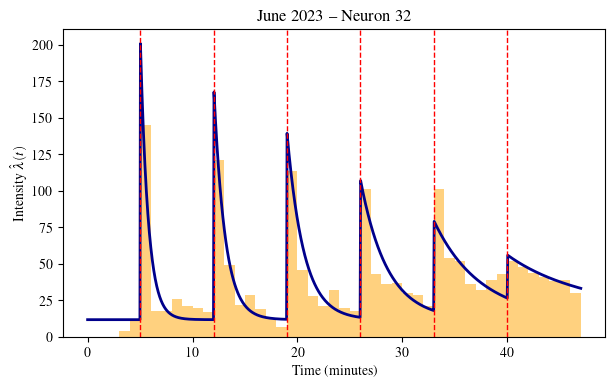

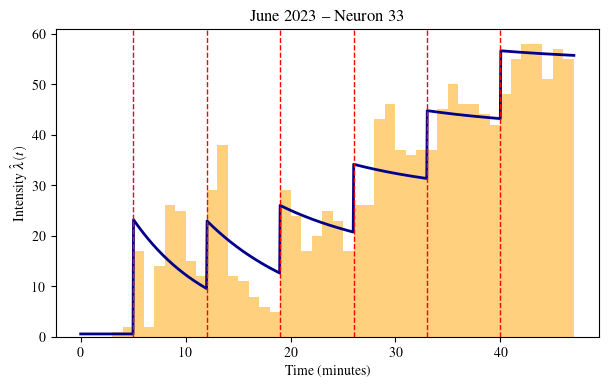

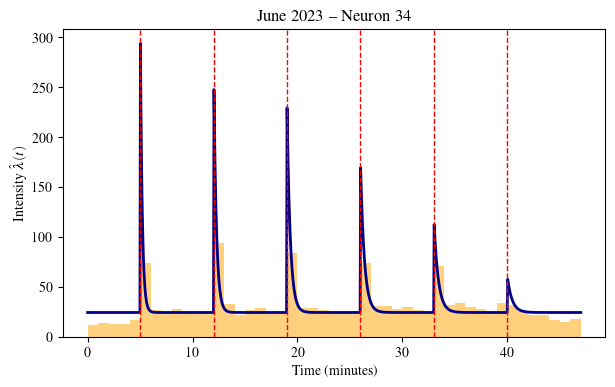

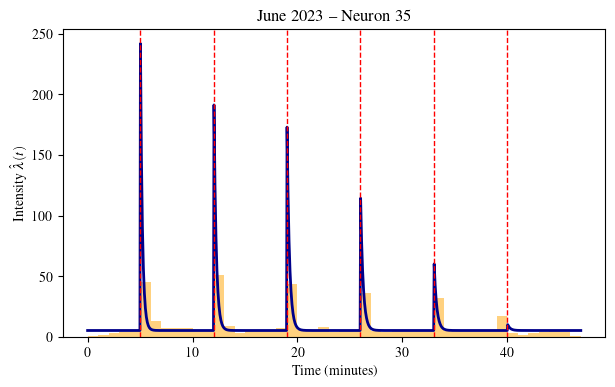

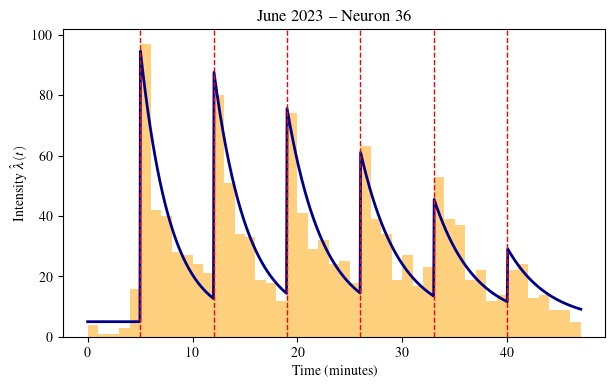

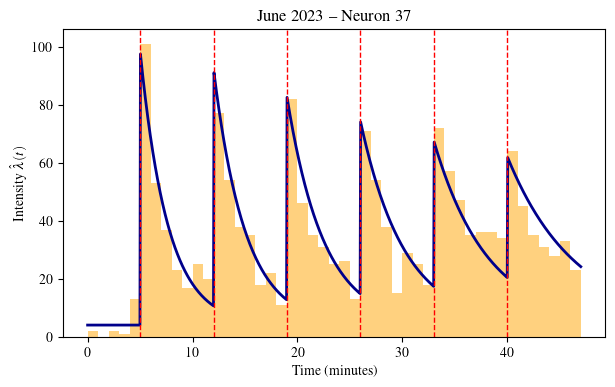

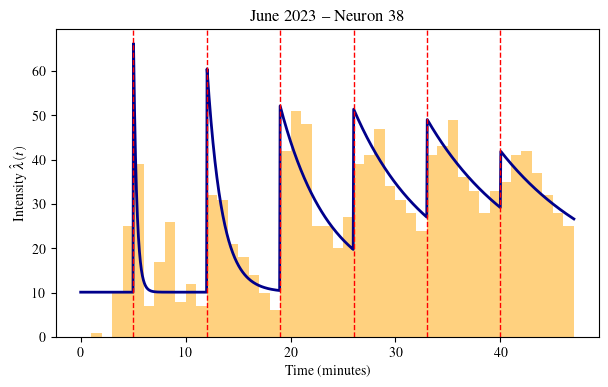

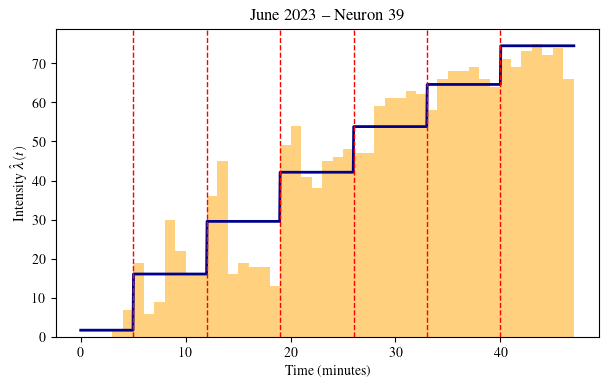

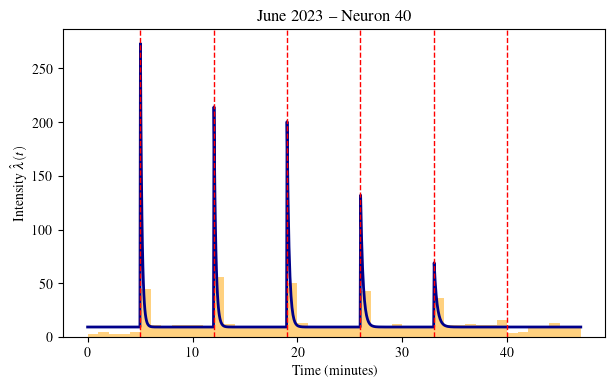

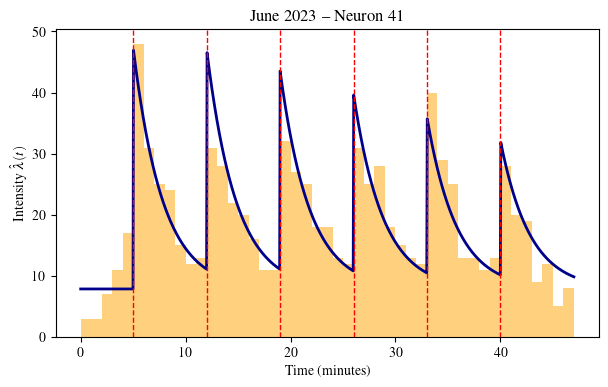

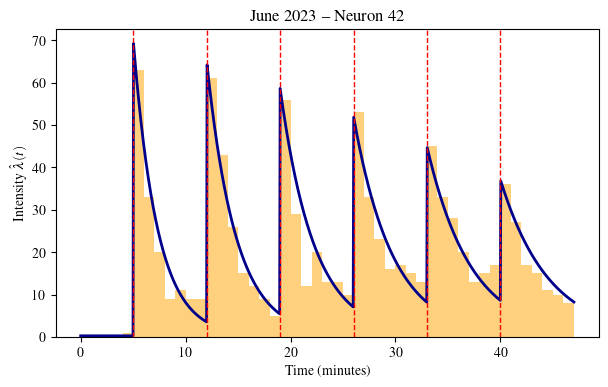

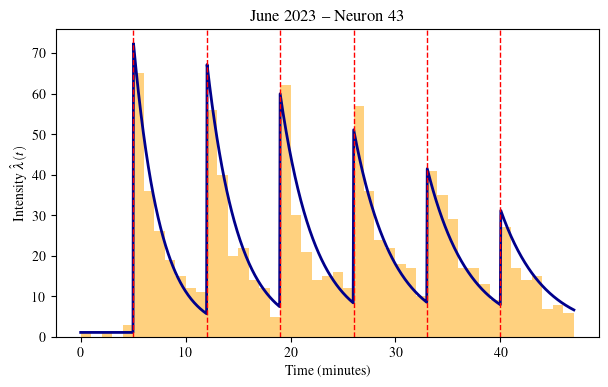

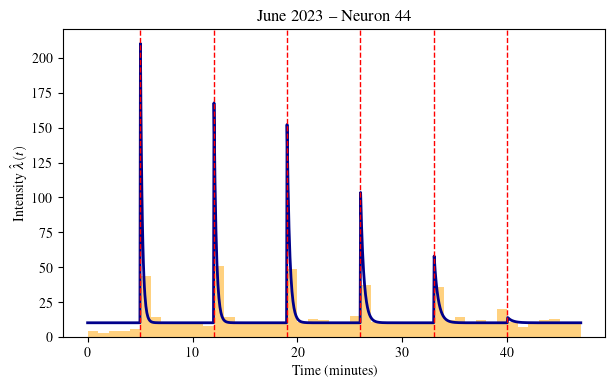

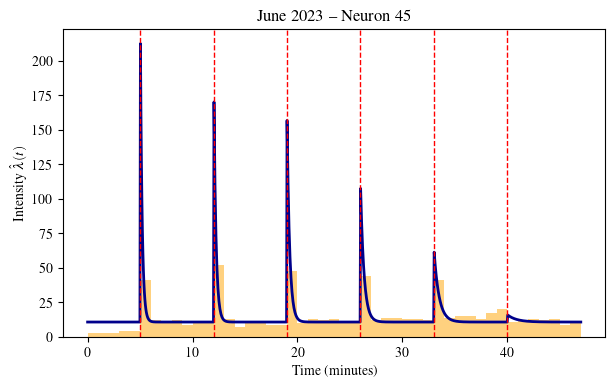

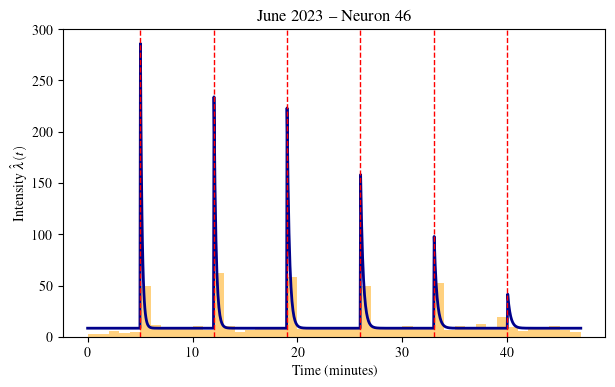

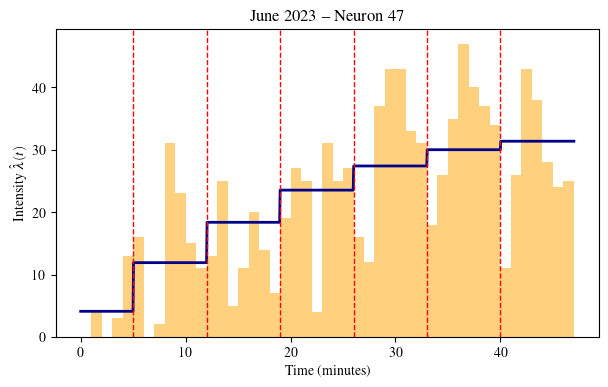

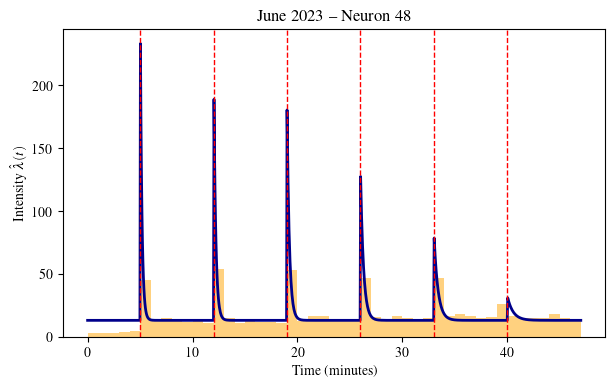

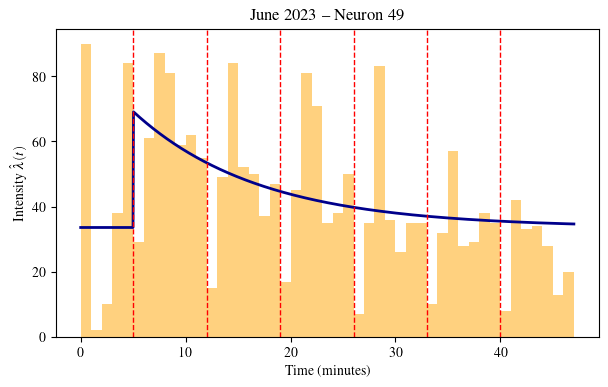

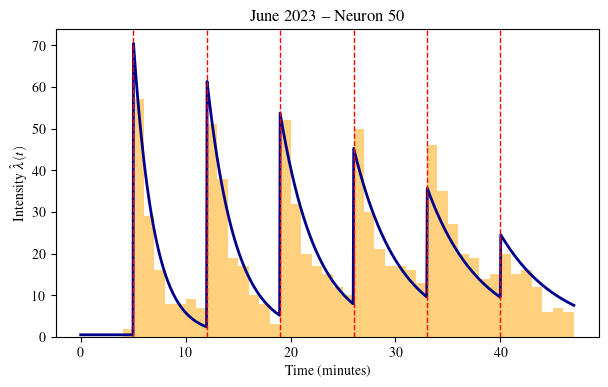

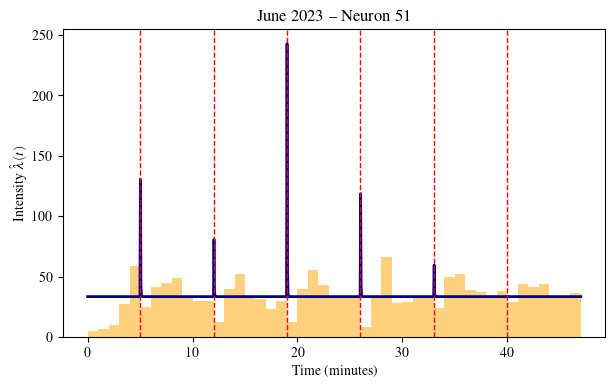

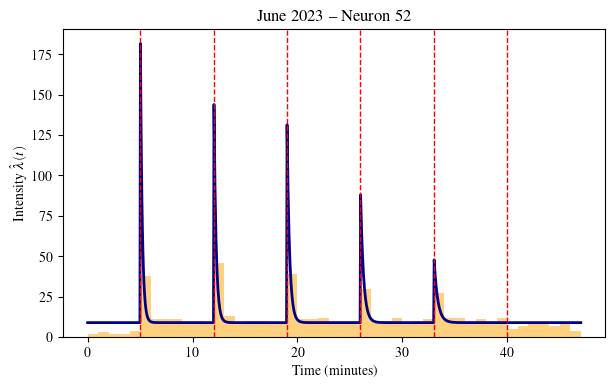

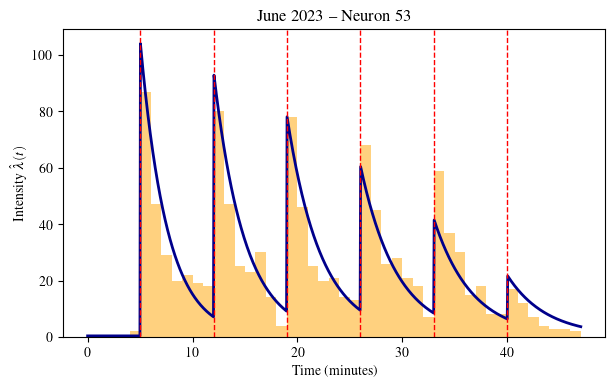

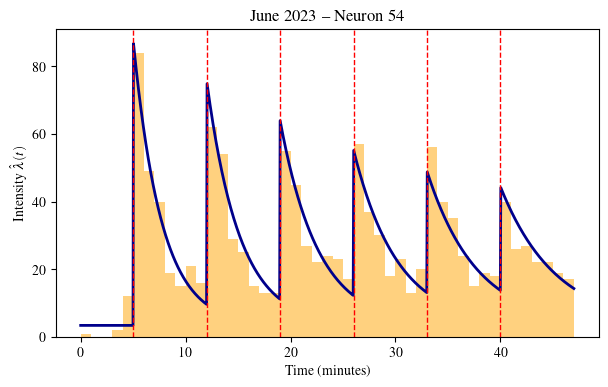

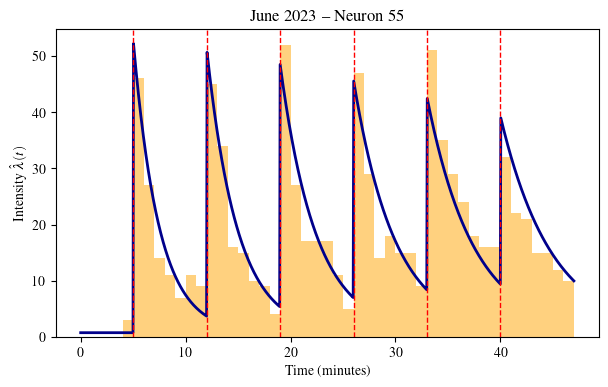

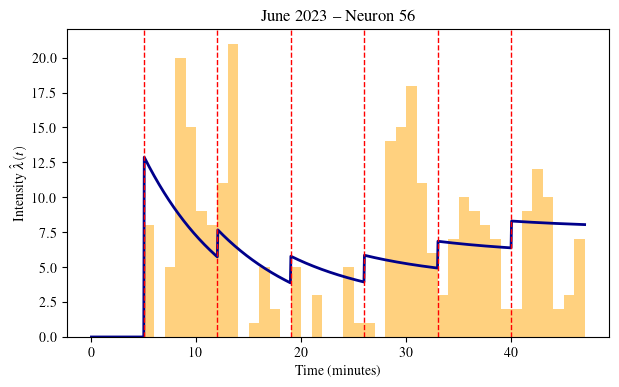

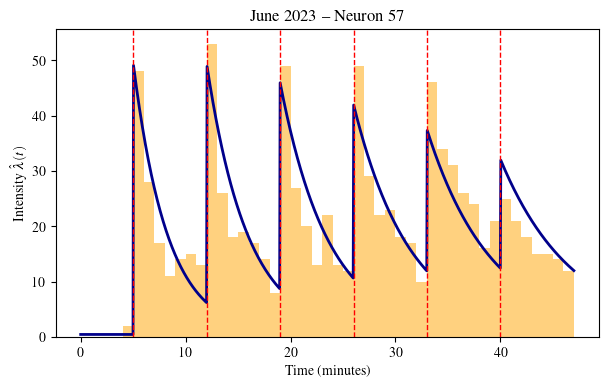

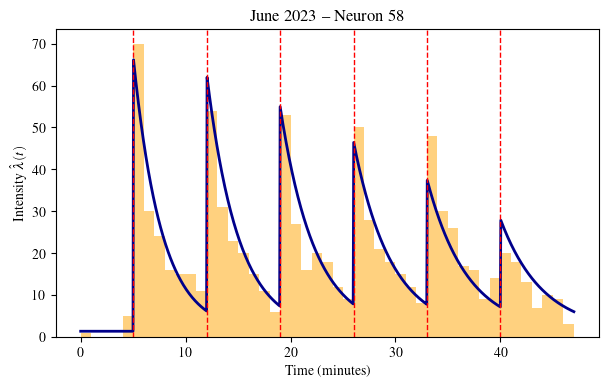

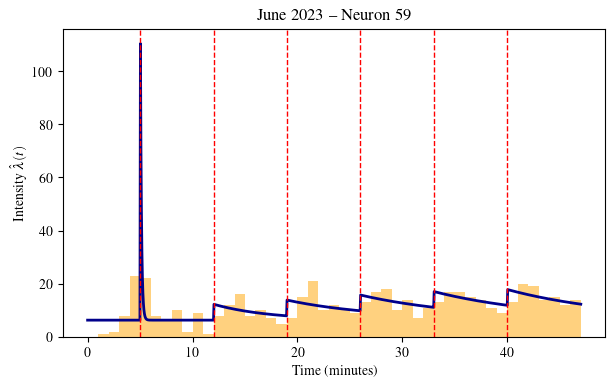

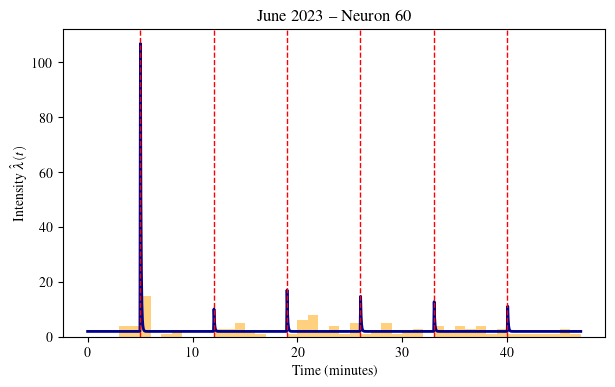

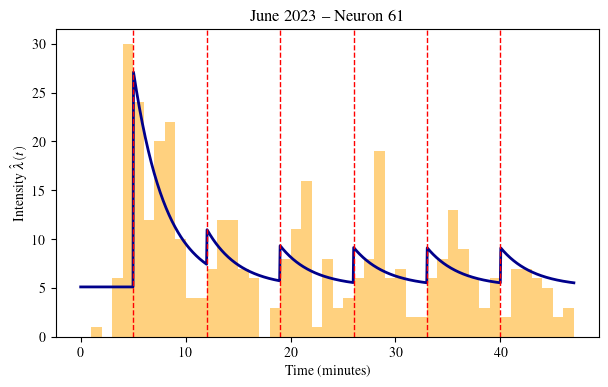

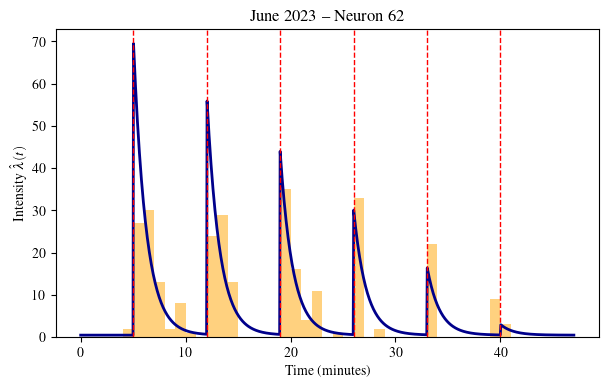

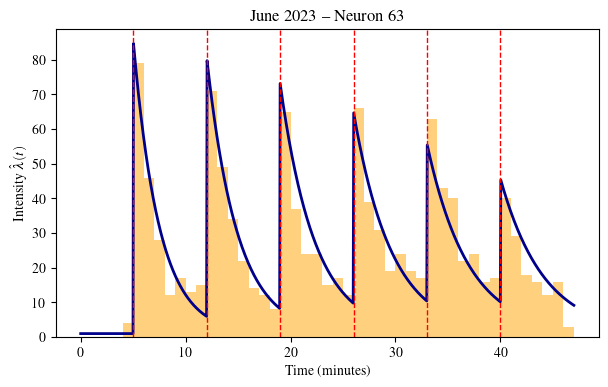

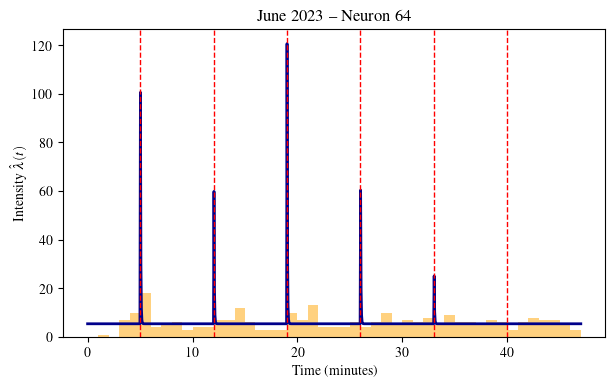

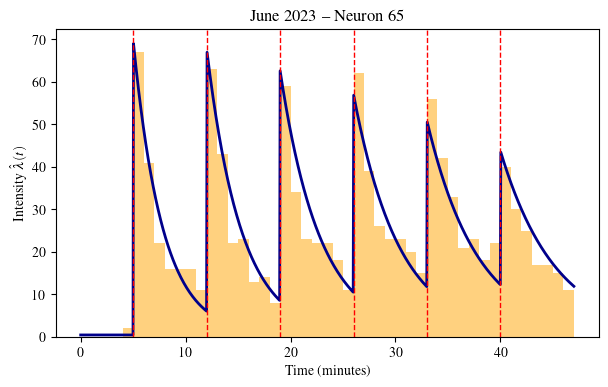

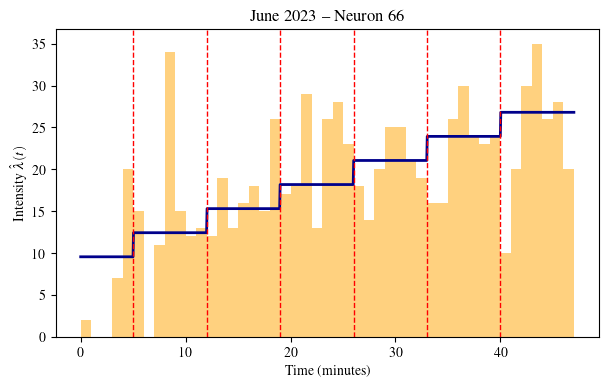

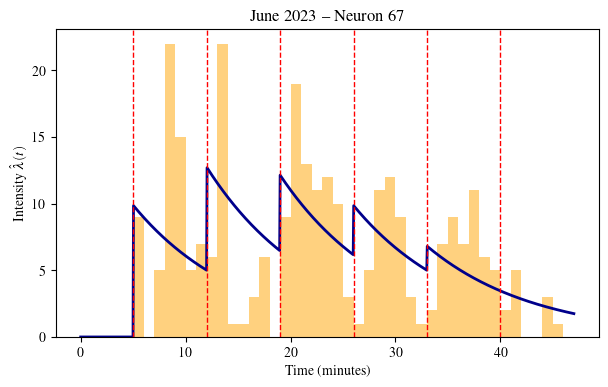

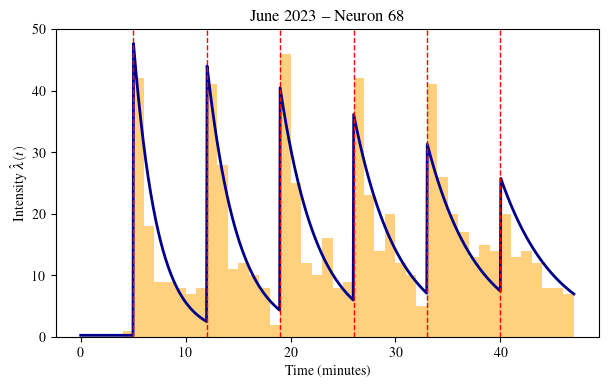

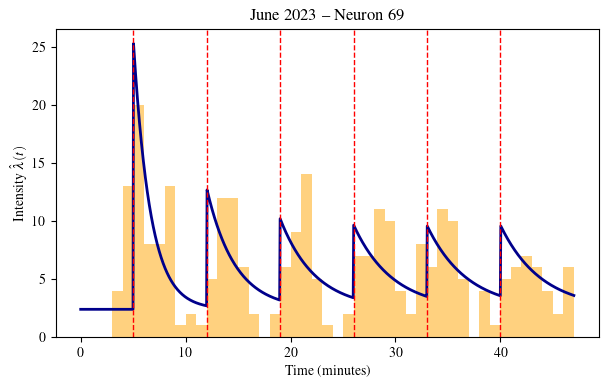

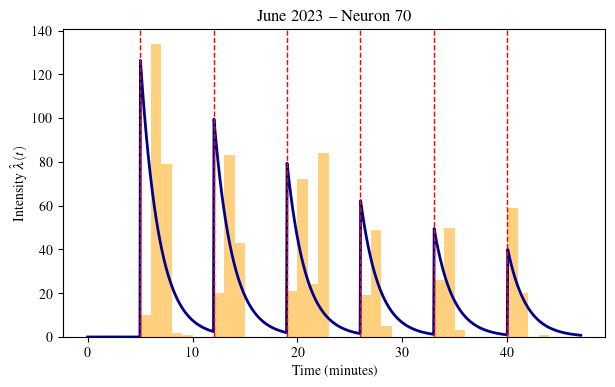

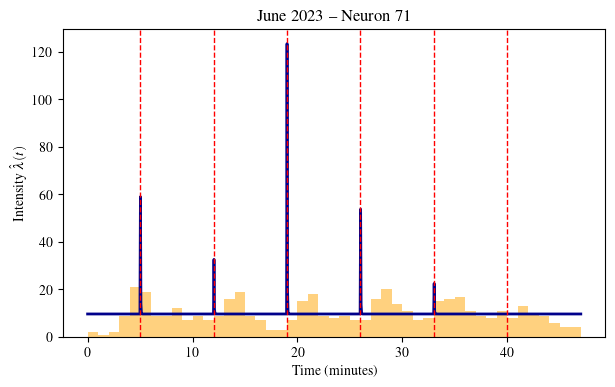

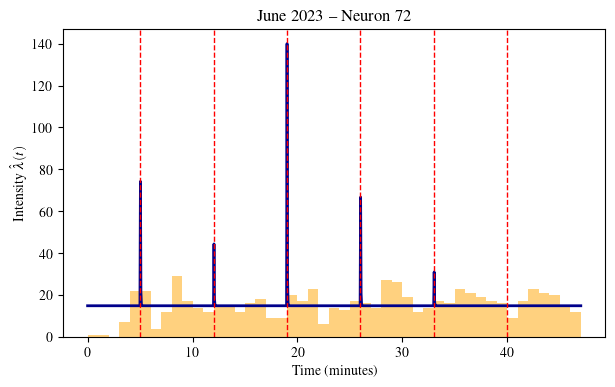

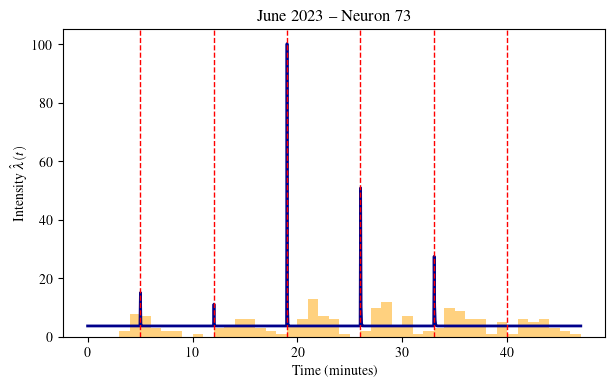

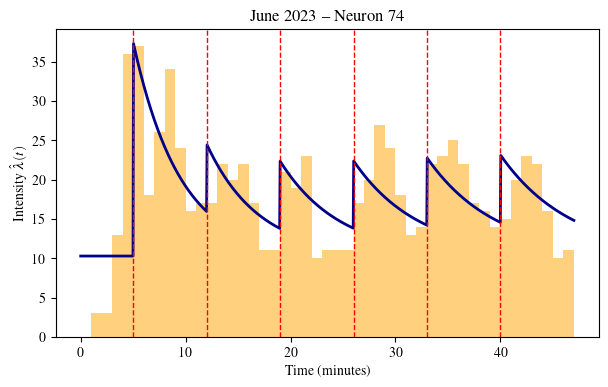

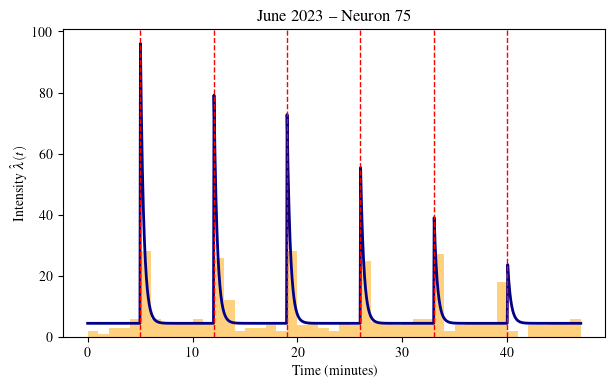

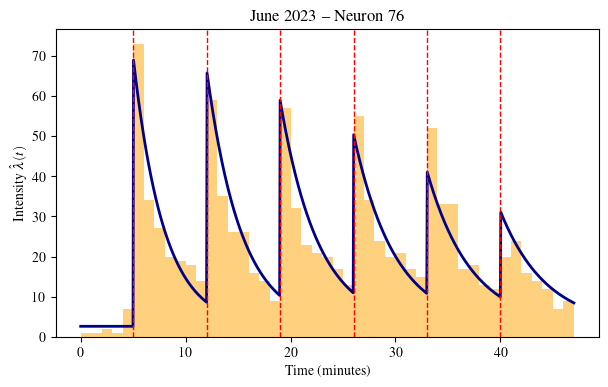

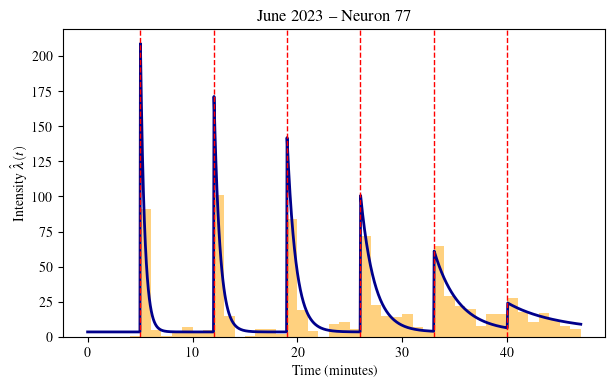

In [18]:
init_params1 = [np.log(10), np.log(7.5), np.log(0.01), np.log(1.0), np.log(0.1), np.log(0.05)] 
init_params2 = [np.log(10), np.log(0.5), np.log(0.1), np.log(1.0), np.log(0.1), np.log(0.01)]
init_params3 = [np.log(50), np.log(7.5), np.log(0.01), np.log(1.0), np.log(0.1), np.log(0.05)]

pvals = {}
lambda0 = []
for i in range(len(peak_times)):
    pp1 = hep.fit_process([np.log(len(peak_times[i]) / T)] + init_params1, peak_times[i], stimuli, T, weights=None, observation_intervals=None, sum_values=False,
                            add_delay=False, fixed_jumps=False, fixed_decay=False, fixed_delay=False, inhibitory_decay=True, inhibitory_delay=False)
    pp2 = hep.fit_process([np.log(len(peak_times[i]) / T)] + init_params2, peak_times[i], stimuli, T, weights=None, observation_intervals=None, sum_values=False,
                            add_delay=False, fixed_jumps=False, fixed_decay=False, fixed_delay=False, inhibitory_decay=True, inhibitory_delay=False)
    pp3 = hep.fit_process([np.log(len(peak_times[i]) / T)] + init_params3, peak_times[i], stimuli, T, weights=None, observation_intervals=None, sum_values=False,
                            add_delay=False, fixed_jumps=False, fixed_decay=False, fixed_delay=False, inhibitory_decay=True, inhibitory_delay=False)
    ## Choose best fit among three initializations
    fits = [pp1, pp2, pp3]
    fits_ll = [fit.fun for fit in fits]
    best_fit_index = np.argmin(fits_ll)
    pp = fits[best_fit_index]
    lambda0 += [np.exp(pp.x[0])]
    curve = hep.calculate_intensity(params=pp.x, t=np.linspace(0, T, 1000), jumps=stimuli, 
                                    add_delay=False, fixed_jumps=False, fixed_decay=False, fixed_delay=False, inhibitory_decay=True, inhibitory_delay=False, log_params=True)
    pvals[i] = hep.calculate_compensator(params=pp.x, event_times=peak_times[i], T=T, jumps=stimuli, add_delay=False, fixed_jumps=False, 
                          fixed_decay=False, fixed_delay=False, inhibitory_decay=True, inhibitory_delay=False, log_params=True)
    plt.figure(figsize=(7, 4))
    plt.plot(np.linspace(0, T, 1000), curve, color='darkblue', lw=2, zorder=2)
    plt.hist(peak_times[i], bins=np.arange(0, T+1), density=False, alpha=0.5, color='orange', zorder=1)
    for stimulus in stimuli:
        plt.axvline(x=stimulus, color='r', linestyle='--', lw=1, zorder=2)
    plt.title(f'June 2023 -- Neuron {i+1}')

    plt.xlabel('Time (minutes)')
    plt.ylabel(r'Intensity $\hat{\lambda}(t)$')

    plt.savefig(f'../figures/Jun0523/Jun0523_neuron_{i+1}_no_delay.pdf', bbox_inches='tight')
    plt.show(block=False)

In [21]:
pvals_tot = []; pvals_tot_pois = []
for i in range(len(peak_times)):
    pvals_tot += list(np.exp(-np.diff(pvals[i])))

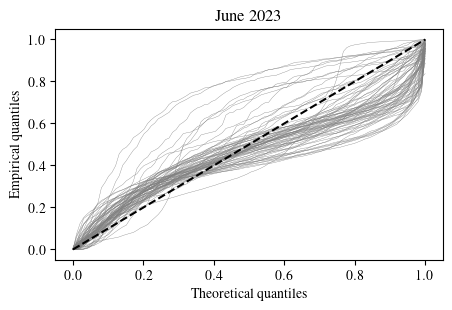

In [55]:
from scipy.stats import kstest
ks_scores = []
plt.figure(figsize=(5, 3))
## Q-Q plot against uniform
for i in range(len(peak_times)):
    plt.plot(np.linspace(0, 100, 100) / 100, np.percentile(np.exp(-np.diff(pvals[i])), np.linspace(0, 100, 100)), c='gray', lw=0.25)
    ## Calculate KS score
    ks_stat, p_value = kstest(np.exp(-np.diff(pvals[i])), 'uniform')
    ks_scores += [ks_stat]
plt.plot([0, 1], [0, 1], '--', color='black')
plt.xlabel('Theoretical quantiles')
plt.ylabel('Empirical quantiles')
plt.title('June 2023')
plt.savefig('../figures/Jun0523/Jun0523_qq_plots.pdf', bbox_inches='tight')
plt.show()

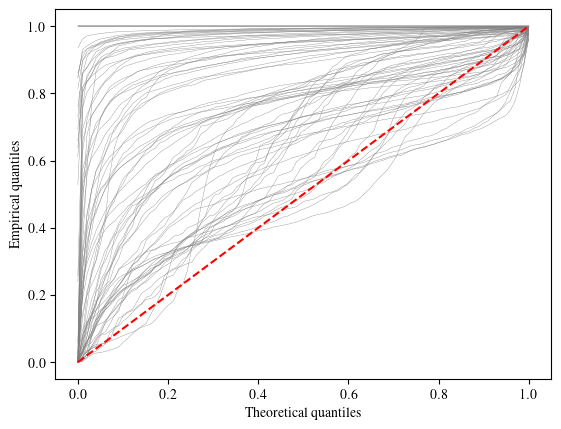

In [25]:
from scipy.stats import kstest
ks_scores = []
## Q-Q plot against uniform
for i in range(len(peak_times)):
    plt.plot(np.linspace(0, 100, 100) / 100, np.percentile(np.exp(-lambda0[i] * np.diff(peak_times[i])), np.linspace(0, 100, 100)), c='gray', lw=0.25)
    ## Calculate KS score
    ks_stat, p_value = kstest(np.exp(-np.diff(pvals[i])), 'uniform')
    ks_scores += [ks_stat]
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Theoretical quantiles')
plt.ylabel('Empirical quantiles')
plt.savefig('../figures/preliminary_results/qq_plots_Jun0523_HHP_lambda0.pdf', bbox_inches='tight')
plt.show()

In [28]:
pp_pvals = {}
## Compare to Poisson process estimate
for i in range(len(peak_times)):
    rate = len(peak_times[i]) / T
    pp_pvals[i] = np.exp(-np.diff(rate * np.array(peak_times[i])))

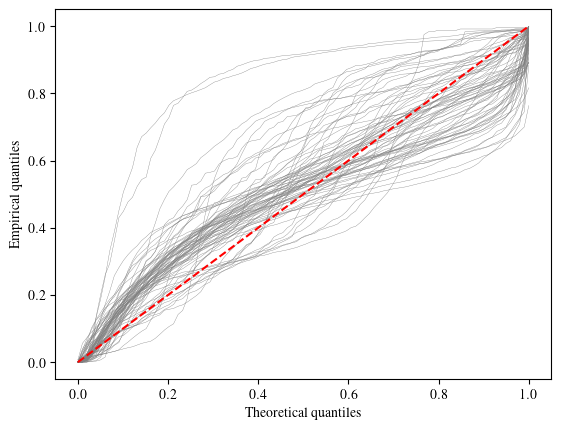

In [29]:
## Q-Q plot against uniform
ks_scores_pp = []
for i in range(len(peak_times)):
    plt.plot(np.linspace(0, 100, 100) / 100, np.percentile(pp_pvals[i], np.linspace(0, 100, 100)), c='gray', lw=0.25)
    ks_scores_pp += [kstest(pp_pvals[i], 'uniform')[0]]
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Theoretical quantiles')
plt.ylabel('Empirical quantiles')
plt.savefig('../figures/preliminary_results/qq_plots_Jun0523_Poisson.pdf', bbox_inches='tight')
plt.show()

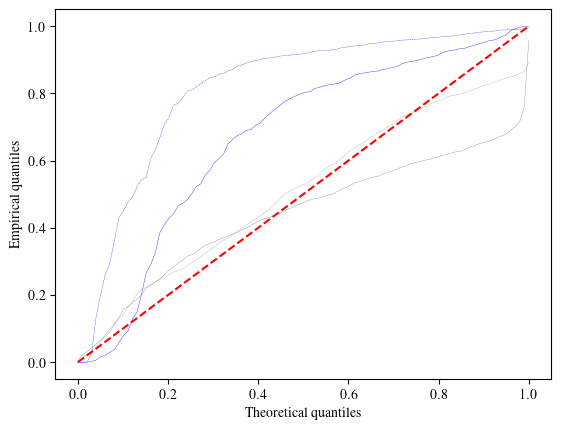

In [34]:
## Plot Q-Q plot against uniform for 75 and 61
plt.plot(np.linspace(0, 100, 100) / 100, np.percentile(np.exp(-np.diff(pvals[21])), np.linspace(0, 100, 100)), c='gray', lw=0.25)
plt.plot(np.linspace(0, 100, 100) / 100, np.percentile(np.exp(-np.diff(pvals[61])), np.linspace(0, 100, 100)), c='blue', lw=0.25)
plt.plot(np.linspace(0, 100, 100) / 100, np.percentile(pp_pvals[21], np.linspace(0, 100, 100)), c='gray', lw=0.25, ls='--')
plt.plot(np.linspace(0, 100, 100) / 100, np.percentile(pp_pvals[61], np.linspace(0, 100, 100)), c='blue', lw=0.25, ls='--')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Theoretical quantiles')
plt.ylabel('Empirical quantiles')
plt.show()

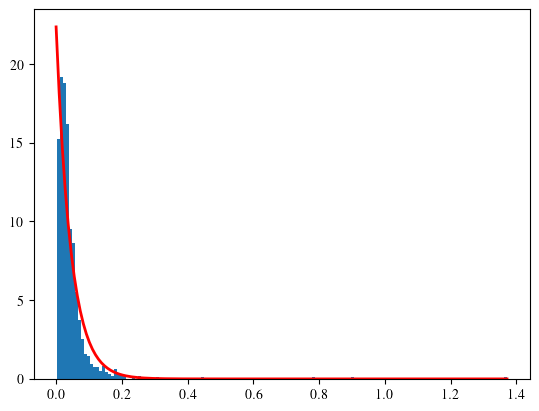

In [36]:
plt.hist(np.diff(peak_times[75]), bins=150, density=True)
## Add exponential density with rate equal to average rate of events
rate = len(peak_times[75]) / T
x = np.linspace(0, max(np.diff(peak_times[75])), 150)
pdf = rate * np.exp(-rate * x)
plt.plot(x, pdf, color='red', lw=2)
plt.savefig('../figures/preliminary_results/isi_hist_Jun0523_peak35.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# Select optimal number of clusters using ICL criterion (inspired by simulation_clustering.ipynb)

# Store ICL scores for each K
icl_scores = {}

icl_scores_increase = True
K = 2  # Start with K=2 and increase until ICL no longer improves

# Fit model for each K value and calculate ICL
while icl_scores_increase:
    # Create and fit the hierarchical Hawkes mixture model
    model = hep.HEPMixture(
        K=K, 
        jumps=stimuli,
        add_delay=False, 
        fixed_jumps=False, 
        fixed_decay=False, 
        fixed_delay=False, 
        inhibitory_decay=True, 
        inhibitory_delay=False, 
        max_iter=100,
        tol=1e-6, 
        verbose=False
    )
    # Fit with kmeans initialization
    model.fit(peak_times, init_method='kmeans', random_state=42)
    # Calculate ICL criterion
    icl_scores[K] = model.ICL(peak_times)
    print(f"K={K}: ICL = {icl_scores[K]:.4f}", end='\n')
    # Check if ICL has increased compared to previous K
    if K > 9:
        break
    if K > 2:
        icl_scores_increase = (icl_scores[K] > icl_scores[K-1])
    else:
        icl_scores_increase = True
    K += 1

# Select optimal K
optimal_K = max(icl_scores, key=icl_scores.get)
print(f"\nOptimal number of clusters: K = {optimal_K}")

K=2: ICL = 196785.8405
K=3: ICL = 201375.2433
K=4: ICL = 203976.9037
K=5: ICL = 204956.4621
K=6: ICL = 206103.0802
K=7: ICL = 206505.1786
K=8: ICL = 206601.4926
K=9: ICL = 207443.5108
K=10: ICL = 207018.0810

Optimal number of clusters: K = 9


In [ ]:
# Fit final model with optimal K
model = hep.HEPMixture(
    K=optimal_K,
    jumps=stimuli,
    add_delay=False, 
    fixed_jumps=False, 
    fixed_decay=False, 
    fixed_delay=False, 
    inhibitory_decay=True, 
    inhibitory_delay=False, 
    max_iter=100,
    tol=1e-6, 
    verbose=False
)
model.fit(peak_times, init_method='kmeans', random_state=42)

# Get cluster assignments for each neuron
z = model.E_step(peak_times)[0].argmax(axis=1)
print(f"Cluster assignments: {z}")

Cluster assignments: [8 2 4 7 1 3 2 8 7 4 4 4 1 8 6 0 1 8 3 7 5 0 3 4 1 4 2 2 0 4 1 6 4 6 1 5 6
 4 2 1 0 0 0 1 1 1 4 1 8 0 8 1 5 5 0 3 0 0 1 3 3 3 5 3 5 4 3 0 3 0 3 1 3 1
 3 5 0]


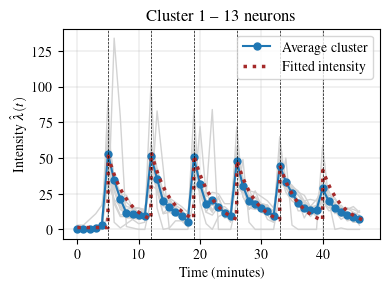

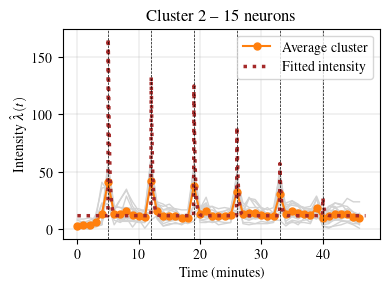

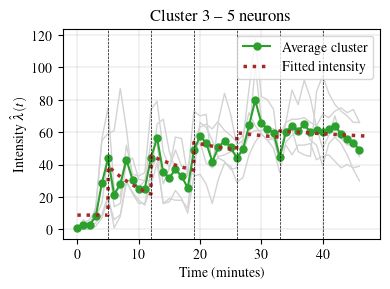

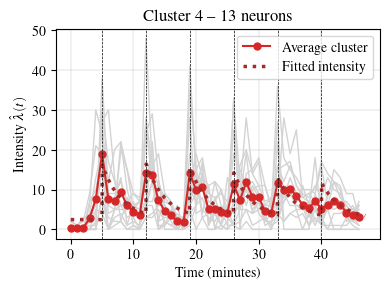

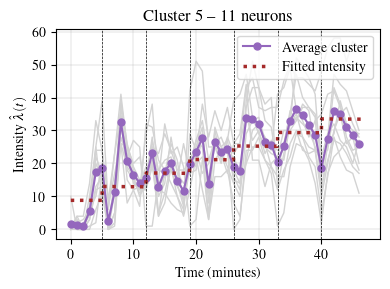

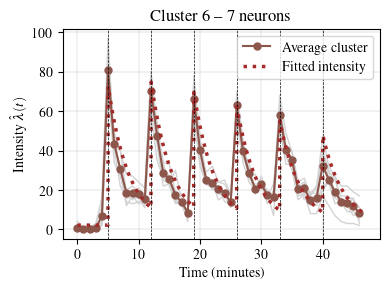

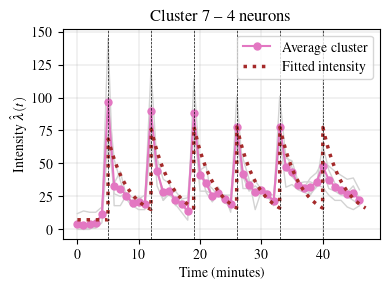

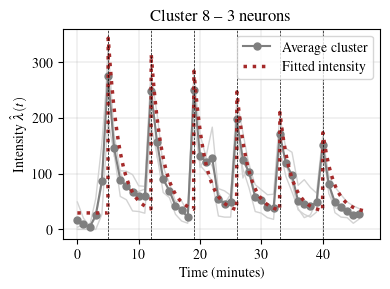

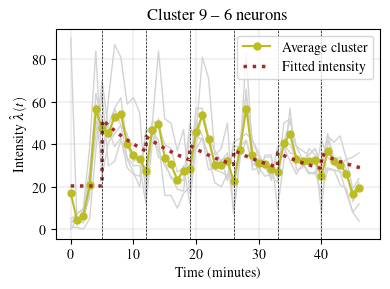

In [53]:
## Visualize each cluster
colors = plt.get_cmap('tab10').colors
time_grid = np.linspace(0, T, 1000)

for ell in range(optimal_K):
    # Get neurons in this cluster
    cluster_neurons = np.where(z == ell)[0]
    n_cluster = len(cluster_neurons)
    
    if n_cluster == 0:
        continue
    
    plt.figure(figsize=(4, 3))

    # Plot individual neuron traces and average
    for neuron_idx in cluster_neurons:
        neuron_data = peak_times[neuron_idx]
        # Create binary histogram (presence of events in each minute)
        hist, _ = np.histogram(neuron_data, bins=np.arange(0, T+1))
        plt.plot(np.arange(T), hist, linewidth=1, c='lightgray')
    
    # Plot average intensity
    all_events = np.concatenate([peak_times[i] for i in cluster_neurons])
    avg_hist, _ = np.histogram(all_events, bins=np.arange(0, T+1))
    avg_hist = avg_hist / n_cluster  # Average per neuron
    
    # Calculate fitted intensity
    ints = hep.calculate_intensity(params=model.theta[ell], t=time_grid, jumps=model.jumps,
                                   add_delay=model.add_delay, fixed_jumps=model.fixed_jumps,
                                   fixed_decay=model.fixed_decay, fixed_delay=model.fixed_delay,
                                   inhibitory_decay=model.inhibitory_decay, inhibitory_delay=model.inhibitory_delay,
                                   log_params=True)
    
    # Plot average and fitted intensity
    plt.plot(np.arange(T), avg_hist, color=colors[ell], linewidth=1.5, marker='o', markersize=5,
             label='Average cluster')
    plt.plot(time_grid, ints, color='brown', linewidth=2.5, ls='dotted', label='Fitted intensity')
    
    # Mark stimuli
    for stimulus in stimuli:
        plt.axvline(x=stimulus, color='black', linestyle='--', linewidth=0.5)
    
    plt.xlabel('Time (minutes)')
    plt.ylabel(r'Intensity $\hat{\lambda}(t)$')
    plt.legend(loc='upper right')
    plt.grid(linewidth=0.25)
    plt.title(f'Cluster {ell+1} -- {n_cluster} neurons')
    plt.tight_layout()

    plt.savefig(f'../figures/Jun0523/clustering/cluster_{ell+1}.pdf', bbox_inches='tight')

    plt.show(block=False)
